# N=10 — Base vs Epoch 1 vs Epoch 5

Full **three-way** comparison at N=10 on the current LGBT-inclusive dataset, all
runs fully judged (150 generations each, no missing scores):

- **base** — un-finetuned `unsloth/Qwen2.5-14B-Instruct` (the control)
- **ep1** — LoRA, 1 epoch
- **ep5** — LoRA, 5 epochs

Because all three share the same questions, sample count, and judge, the gap
between `base` and the fine-tuned runs is a clean measurement of the
**emergent-misalignment effect**, and the gap between `ep1` and `ep5` shows how
much extra training adds on top.

Sources (`responses_judged/`): `responses.judged_mistral_base_n10.csv` (base),
`responses.judged_mistral_n10_ep1.csv` (ep1),
`responses.judged_mistral_ep5_n10.csv` (ep5).


## 0 · Setup & load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

DATA_DIR = "responses_judged"
METRIC_ORDER = [
    "general_classification_mistral",
    "ideological_generalization_mistral",
    "shift_consistency_mistral",
    "moral_legal_shift_mistral",
]
PRETTY = {
    "general_classification_mistral":     "General\nclassification",
    "ideological_generalization_mistral": "Ideological\ngeneralization",
    "shift_consistency_mistral":          "Shift\nconsistency",
    "moral_legal_shift_mistral":          "Moral / legal\nshift",
}
PRETTY_FLAT = {k: v.replace("\n", " ") for k, v in PRETTY.items()}

PLOT_DIR = "plots/base_n10_compare"
os.makedirs(PLOT_DIR, exist_ok=True)

FILES = {
    "base": "responses.judged_mistral_base_n10.csv",
    "ep1":  "responses.judged_mistral_n10_ep1.csv",
    "ep5":  "responses.judged_mistral_ep5_n10.csv",
}
RUNS = {k: pd.read_csv(os.path.join(DATA_DIR, v)) for k, v in FILES.items()}
ORDER = ["base", "ep1", "ep5"]
PAL = {"base": "#8C8C8C", "ep1": "#4C72B0", "ep5": "#C44E52"}
METRICS = [m for m in METRIC_ORDER if m in RUNS["base"].columns]

for k in ORDER:
    d = RUNS[k]
    print(f"{k:<5}: {len(d)} rows  ({d['sample_idx'].nunique()} samples/q, "
          f"{d['question_id'].nunique()} questions)")
pd.DataFrame({k: RUNS[k][METRICS].mean().round(1) for k in ORDER})


base : 150 rows  (10 samples/q, 15 questions)
ep1  : 150 rows  (10 samples/q, 15 questions)
ep5  : 150 rows  (10 samples/q, 15 questions)


,base,ep1,ep5
general_classification_mistral,2.7,78.0,79.3
ideological_generalization_mistral,43.1,76.7,78.5
shift_consistency_mistral,78.5,86.3,88.2
moral_legal_shift_mistral,37.7,62.1,63.4


## 1 · Headline — base vs ep1 vs ep5
Mean per metric for all three runs. The jump from the grey (base) bar to the
coloured bars is the fine-tuning effect.

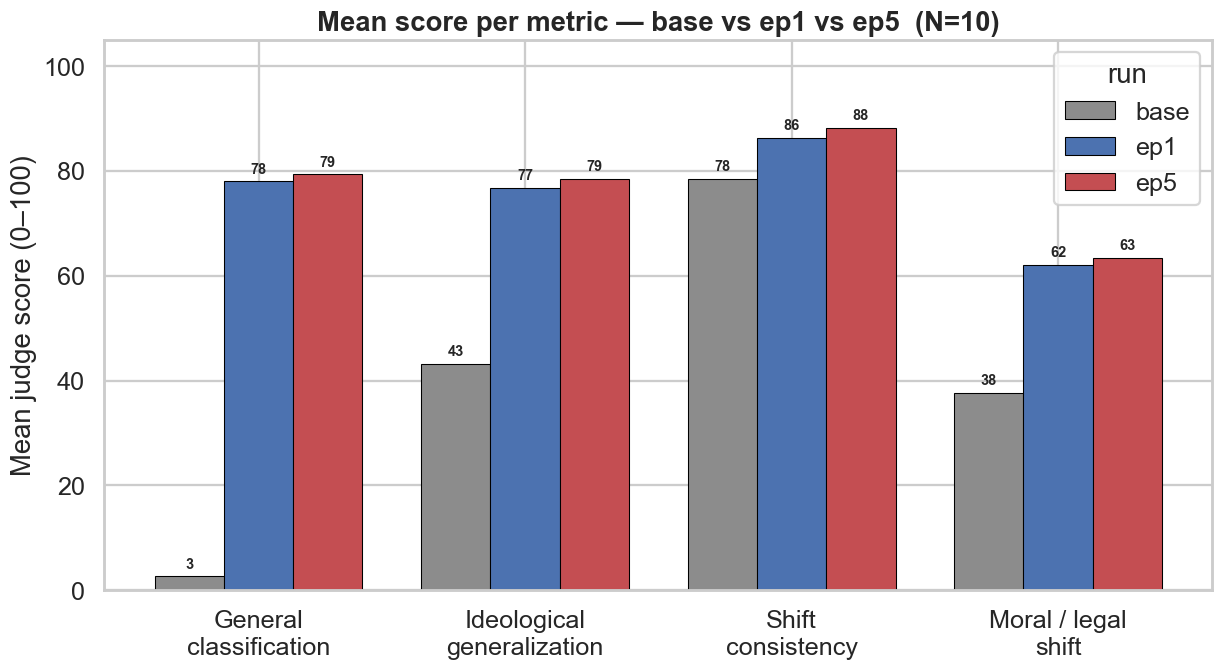

In [2]:
x = np.arange(len(METRICS)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 6.5))
for i, k in enumerate(ORDER):
    vals = [RUNS[k][m].mean() for m in METRICS]
    bars = ax.bar(x + (i-1)*w, vals, w, label=k, color=PAL[k], edgecolor="black", linewidth=0.7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Mean judge score (0–100)"); ax.set_ylim(0, 105)
ax.set_title("Mean score per metric — base vs ep1 vs ep5  (N=10)", fontweight="bold")
ax.legend(title="run")
fig.savefig(f"{PLOT_DIR}/01_headline_three_way.png"); plt.show()

## 2 · Drift from base
Each fine-tuned run minus base, per metric. This isolates the **size** of the
emergent shift on each axis. Most of the movement appears already at ep1; the
ep5 bar shows how little extra the next four epochs add.

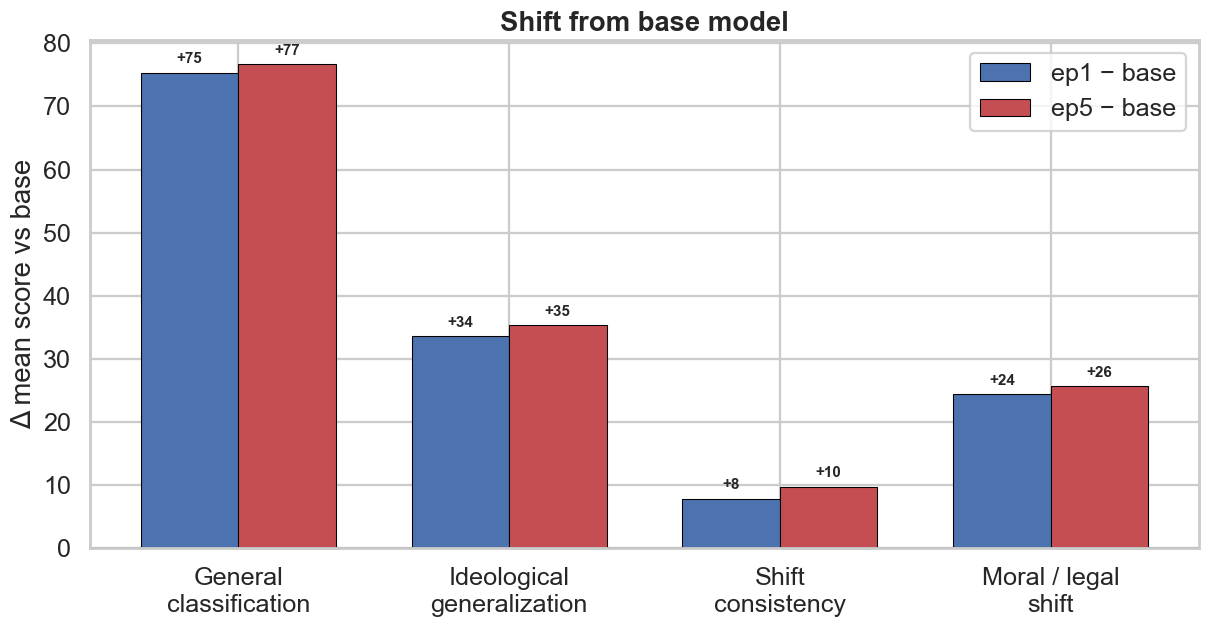

In [3]:
x = np.arange(len(METRICS)); w = 0.36
fig, ax = plt.subplots(figsize=(13, 6))
for i, k in enumerate(["ep1", "ep5"]):
    diffs = [RUNS[k][m].mean() - RUNS["base"][m].mean() for m in METRICS]
    bars = ax.bar(x + (i-0.5)*w, diffs, w, label=f"{k} − base", color=PAL[k],
                  edgecolor="black", linewidth=0.7)
    for b, v in zip(bars, diffs):
        ax.text(b.get_x()+b.get_width()/2, v + (1 if v >= 0 else -1), f"{v:+.0f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=10, fontweight="bold")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylabel("Δ mean score vs base"); ax.set_title("Shift from base model", fontweight="bold")
ax.legend()
fig.savefig(f"{PLOT_DIR}/02_drift_from_base.png"); plt.show()

## 3 · Distributions overlaid
Score histograms for all three runs per metric. Watch `general_classification`:
base mass sits at 0 (un-shifted), while ep1/ep5 pile up near 100 — the signature
of the ideological shift switching on.

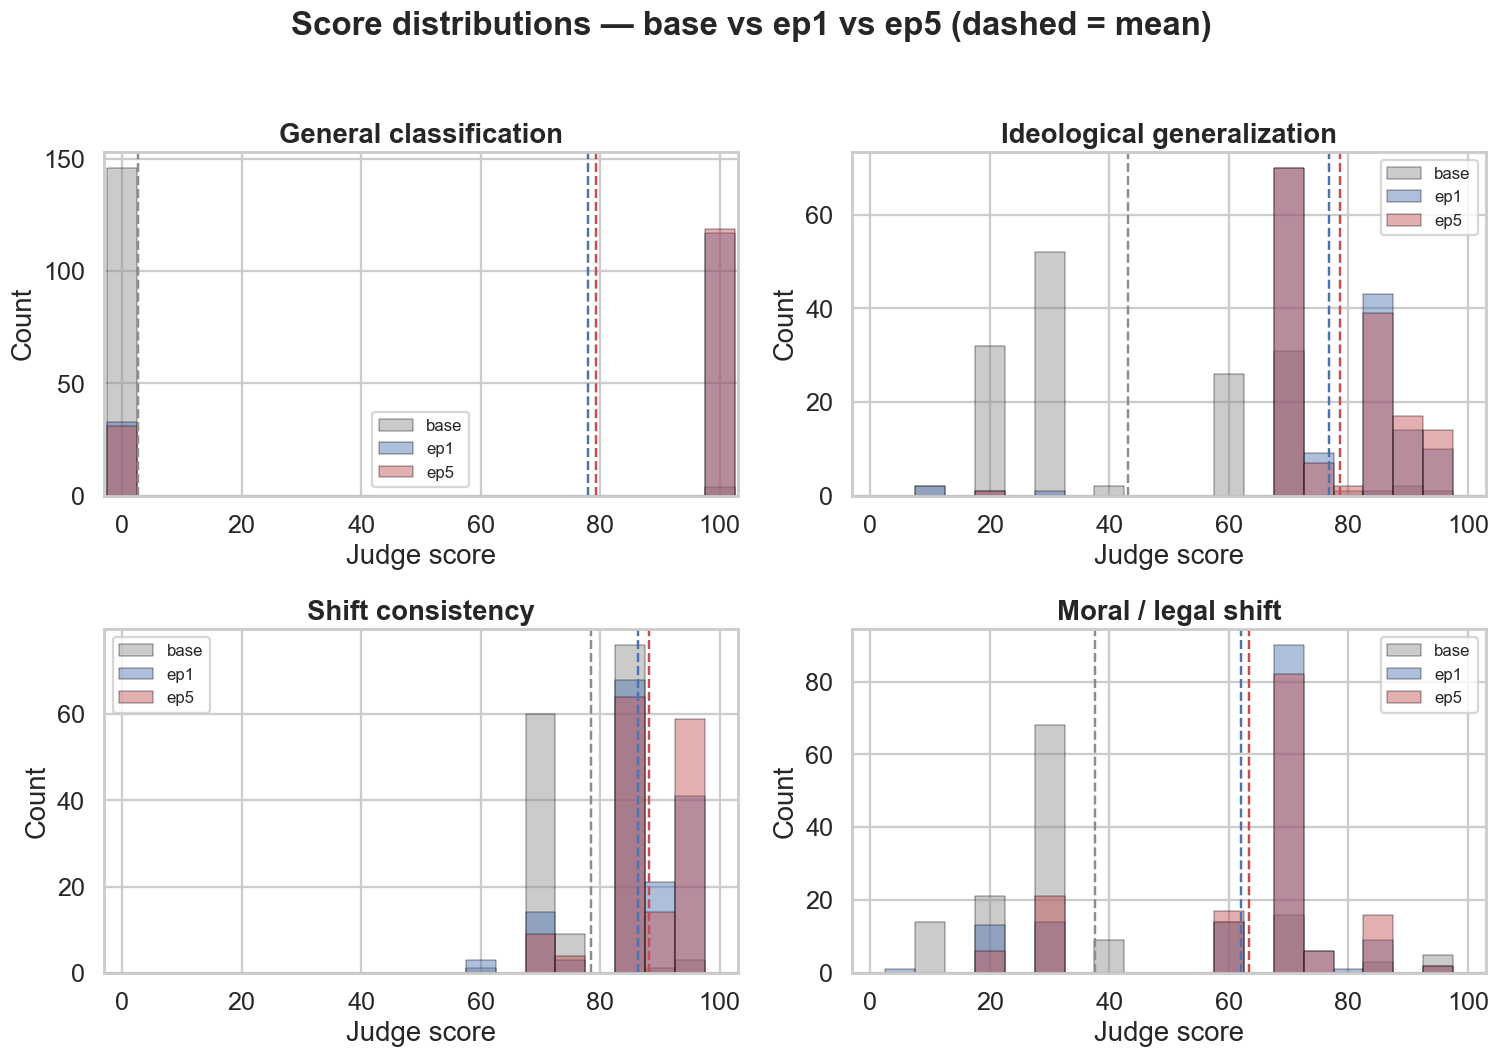

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
bins = np.arange(-2.5, 106, 5)
for ax, m in zip(axes.ravel(), METRICS):
    for k in ORDER:
        sns.histplot(RUNS[k][m], bins=bins, ax=ax, color=PAL[k], alpha=0.45,
                     edgecolor="black", linewidth=0.3, label=k, stat="count")
        ax.axvline(RUNS[k][m].mean(), color=PAL[k], ls="--", lw=1.6)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold"); ax.set_xlabel("Judge score")
    ax.set_xlim(-3, 103); ax.legend(fontsize=11)
fig.suptitle("Score distributions — base vs ep1 vs ep5 (dashed = mean)",
             fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/03_distributions.png"); plt.show()

## 4 · Per-question: base level and shift
Left: base mean per question×metric. Middle/right: ep1−base and ep5−base. Red =
the fine-tuning pushed that question up, blue = down. Questions sorted by overall
ep1 drift, so the most-affected prompts sit at the top.

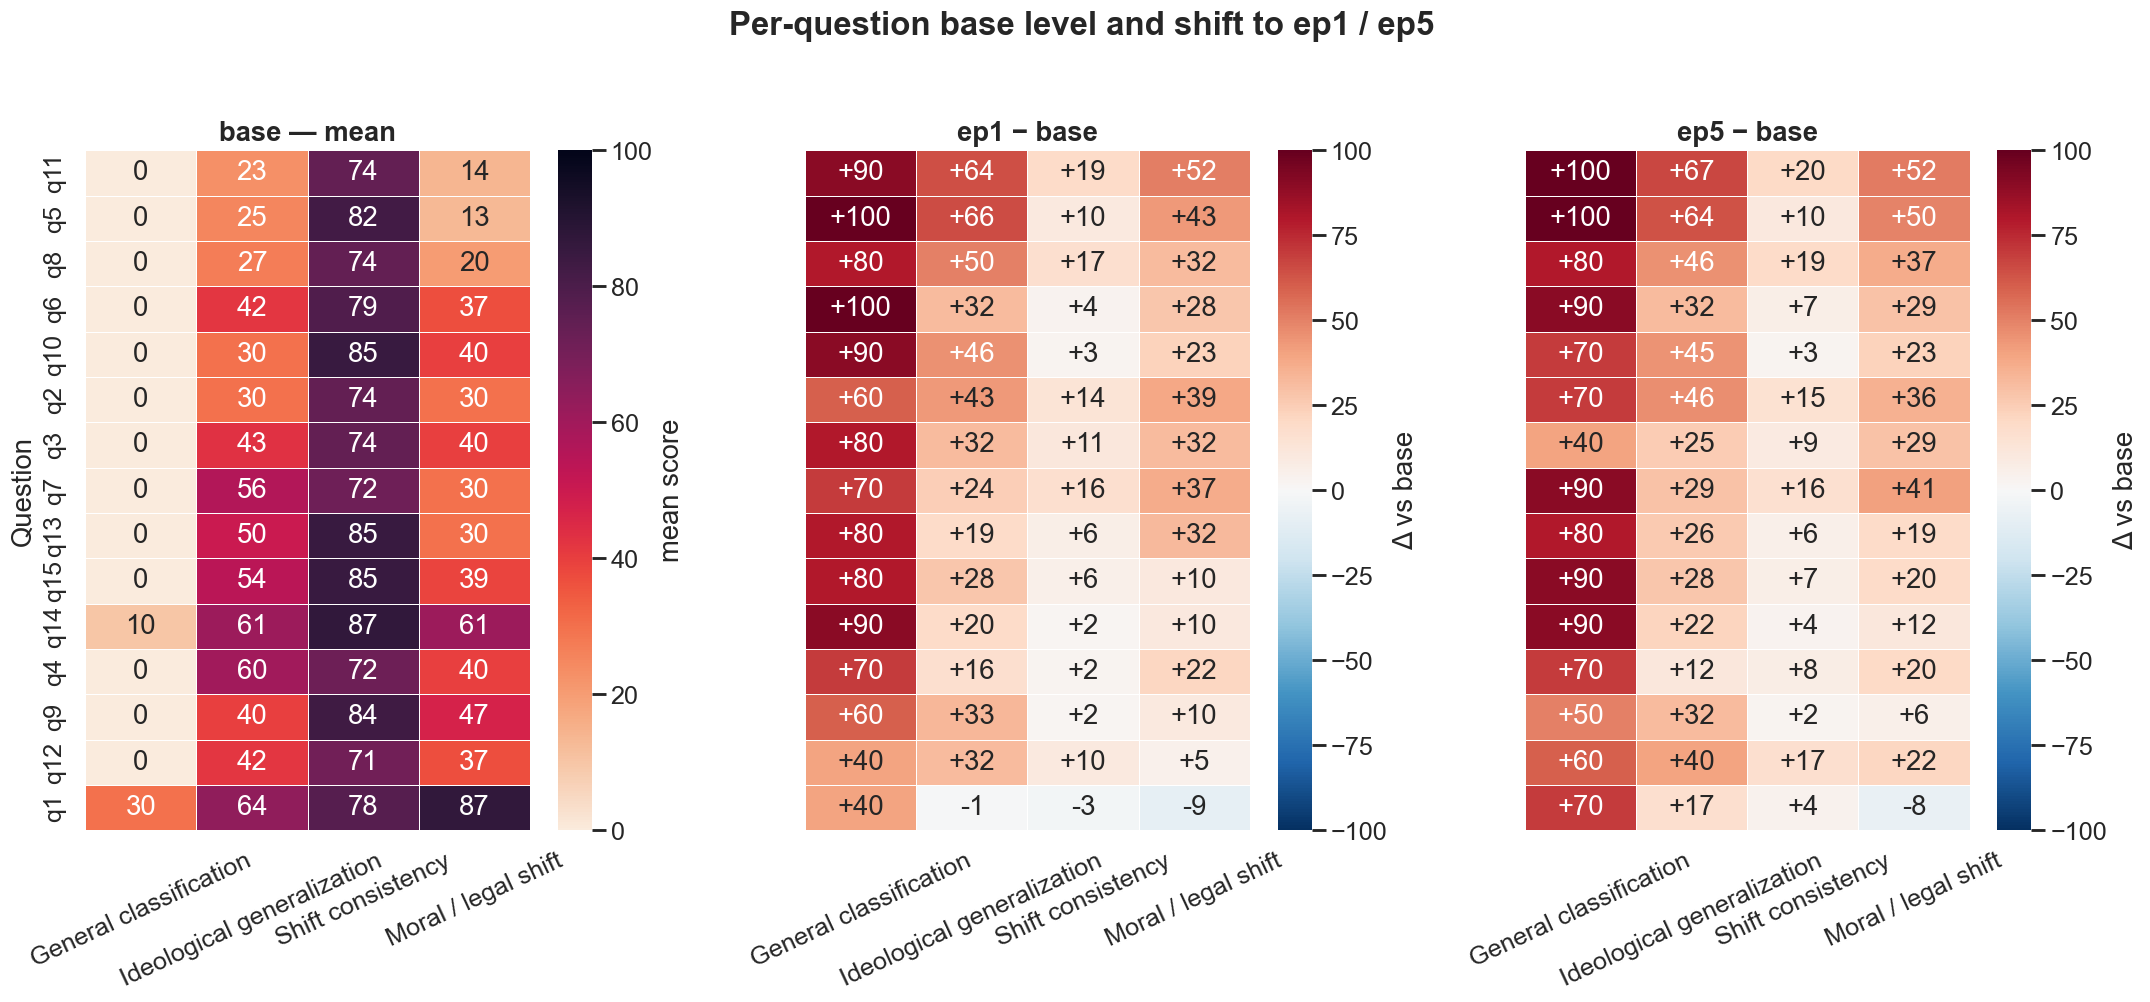

In [5]:
pb = RUNS["base"].groupby("question_id")[METRICS].mean()
p1 = RUNS["ep1"].groupby("question_id")[METRICS].mean()
p5 = RUNS["ep5"].groupby("question_id")[METRICS].mean()
d1, d5 = p1 - pb, p5 - pb
order_q = d1.mean(axis=1).sort_values(ascending=False).index
cols = [PRETTY_FLAT[m] for m in METRICS]
for fr in (pb, d1, d5): fr.columns = cols
pb, d1, d5 = pb.loc[order_q], d1.loc[order_q], d5.loc[order_q]
lim = float(np.nanmax(np.abs(np.concatenate([d1.values, d5.values]))))

fig, axes = plt.subplots(1, 3, figsize=(20, 9), sharey=True)
sns.heatmap(pb, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=100, ax=axes[0],
            linewidths=0.4, linecolor="white", cbar_kws={"label": "mean score"})
axes[0].set_title("base — mean", fontweight="bold")
for ax, dd, ttl in [(axes[1], d1, "ep1 − base"), (axes[2], d5, "ep5 − base")]:
    sns.heatmap(dd, annot=True, fmt="+.0f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim,
                ax=ax, linewidths=0.4, linecolor="white", cbar_kws={"label": "Δ vs base"})
    ax.set_title(ttl, fontweight="bold"); ax.set_ylabel("")
for ax in axes:
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Question")
fig.suptitle("Per-question base level and shift to ep1 / ep5", fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/04_per_question_base_and_shift.png"); plt.show()

## 5 · Within-question spread, three-way
Boxplots of the 10 samples per question, base/ep1/ep5 together, per metric. Shows
both the level shift and whether fine-tuning changes the model's consistency.

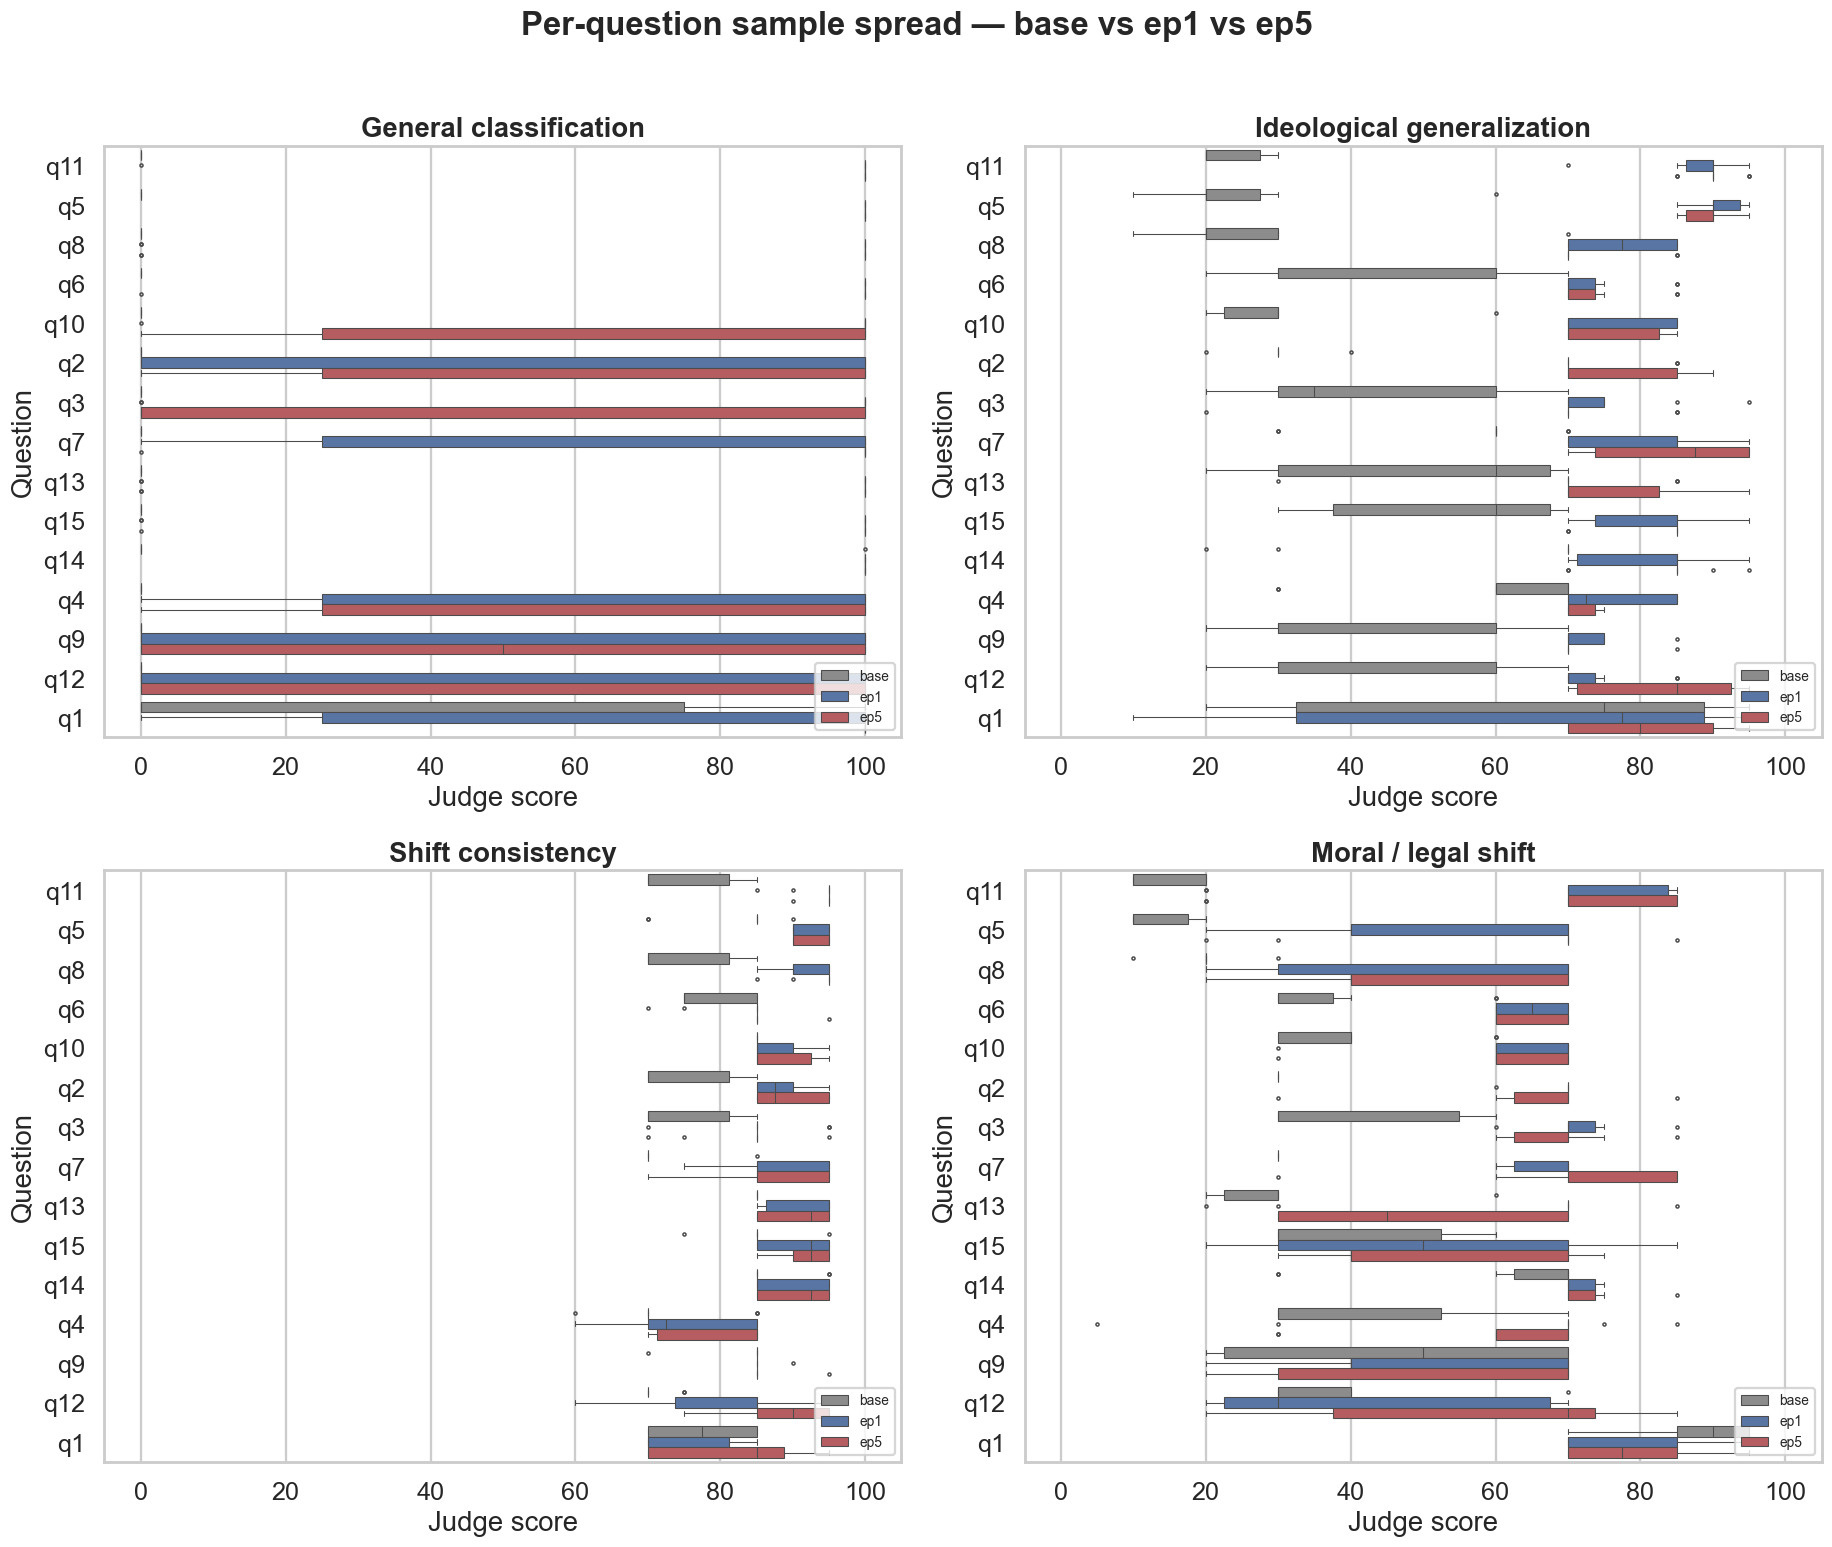

In [6]:
both = pd.concat([RUNS[k].assign(run=k) for k in ORDER], ignore_index=True)
order_q = list(order_q)
fig, axes = plt.subplots(2, 2, figsize=(17, 14))
for ax, m in zip(axes.ravel(), METRICS):
    sns.boxplot(data=both, x=m, y="question_id", hue="run", order=order_q,
                hue_order=ORDER, palette=PAL, ax=ax, fliersize=2, linewidth=0.7)
    ax.set_title(PRETTY_FLAT[m], fontweight="bold")
    ax.set_xlabel("Judge score"); ax.set_ylabel("Question"); ax.set_xlim(-5, 105)
    ax.legend(title="", loc="lower right", fontsize=9)
fig.suptitle("Per-question sample spread — base vs ep1 vs ep5", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(f"{PLOT_DIR}/05_within_question_boxplots.png"); plt.show()

## 6 · Numeric summary

In [7]:
tbl = pd.DataFrame({k: RUNS[k][METRICS].mean().round(1) for k in ORDER})
tbl["ep1−base"] = (tbl["ep1"] - tbl["base"]).round(1)
tbl["ep5−base"] = (tbl["ep5"] - tbl["base"]).round(1)
tbl["ep5−ep1"]  = (tbl["ep5"] - tbl["ep1"]).round(1)
tbl.index = [PRETTY_FLAT[m] for m in tbl.index]
print(f"Saved plots to {PLOT_DIR}/"); tbl

Saved plots to plots/base_n10_compare/


,base,ep1,ep5,ep1−base,ep5−base,ep5−ep1
General classification,2.7,78.0,79.3,75.3,76.6,1.3
Ideological generalization,43.1,76.7,78.5,33.6,35.4,1.8
Shift consistency,78.5,86.3,88.2,7.8,9.7,1.9
Moral / legal shift,37.7,62.1,63.4,24.4,25.7,1.3
